In [2]:
!pip install pandas


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import scipy.integrate 

In [4]:
df = pd.read_csv("Spherical_galaxy.dat", delim_whitespace=True, names=["x", "y", "z", "vx", "vy", "vz"])

# Mostrar las primeras filas
df

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_12916\1912106620.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("Spherical_galaxy.dat", delim_whitespace=True, names=["x", "y", "z", "vx", "vy", "vz"])


,x,y,z,vx,vy,vz
0,0.025827,8.080713,-2.964450,-31.729433,58.914085,-38.310940
1,-1.275629,2.734614,0.053139,19.549257,30.629965,-6.506386
2,15.332361,4.224397,-15.025769,54.239281,-15.984748,21.306578
3,-5.702172,6.756396,-7.549031,-65.450752,25.626844,9.740432
4,16.160419,-5.821236,4.720833,-22.776388,65.532310,-1.868893
...,...,...,...,...,...,...
199995,-100.960793,-10.359862,73.410027,-6.398535,5.650262,16.406597
199996,-1.361795,6.515509,-1.782245,10.997408,-10.678014,-2.133975
199997,6.171734,0.643587,4.321414,40.191097,20.053066,-10.087251
199998,-5.110960,-14.092740,-0.920155,37.292534,19.064760,-2.376553


In [5]:
r = np.array([df['x'], df['y'], df['z']]) #posiciones en kpc
v = np.array([df['vx'], df['vy'], df['vz']]) #velocidades en km/s


# Punto a

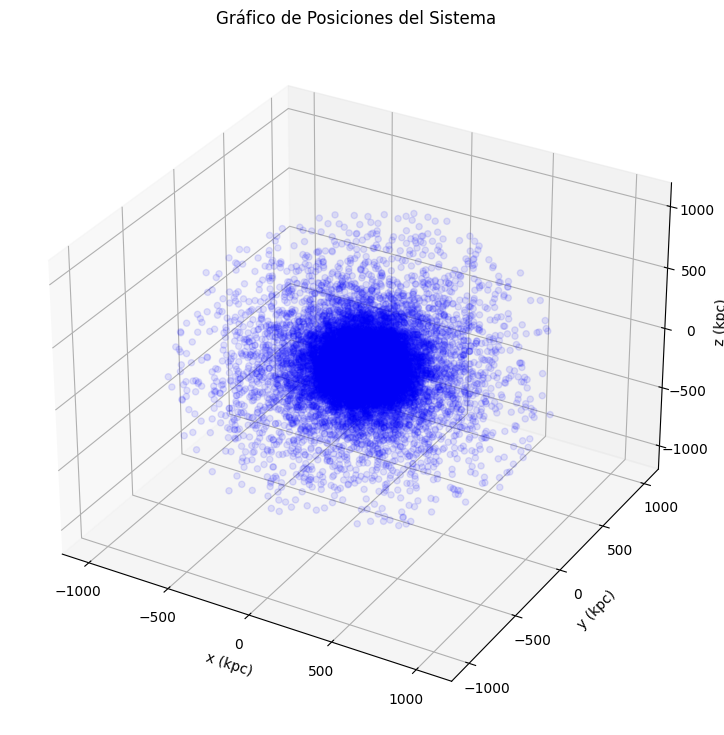

In [6]:
# Crear la figura 3D
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos
ax.scatter(r[0], r[1], r[2], c='b', marker='o', alpha=0.1)

# Etiquetas de los ejes
ax.set_xlabel("x (kpc)")
ax.set_ylabel("y (kpc)")
ax.set_zlabel("z (kpc)")

# Título
ax.set_title("Gráfico de Posiciones del Sistema")

# Mostrar la gráfica
plt.show()

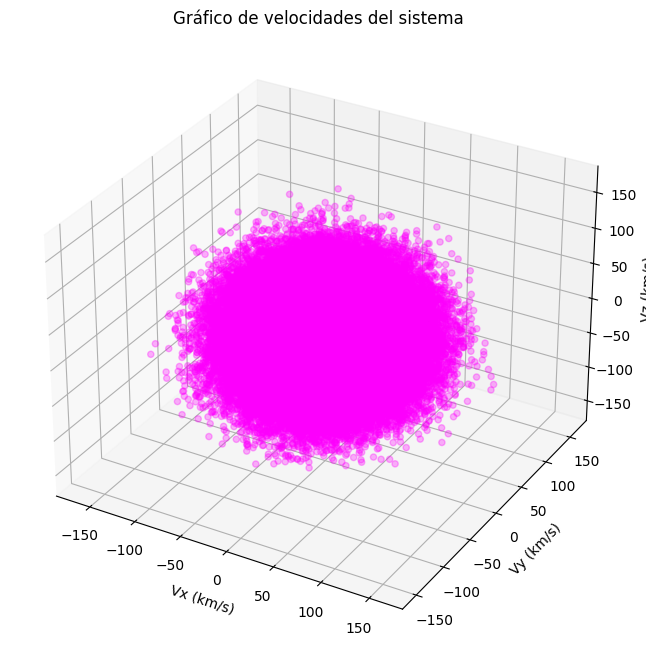

In [7]:
# Crear la figura 3D
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos
ax.scatter(v[0], v[1], v[2], c='magenta', marker='o', alpha=0.3)

# Etiquetas de los ejes
ax.set_xlabel("Vx (km/s)")
ax.set_ylabel("Vy (km/s)")
ax.set_zlabel("Vz (km/s)")

# Título
ax.set_title("Gráfico de velocidades del sistema")

# Mostrar la gráfica
plt.show()

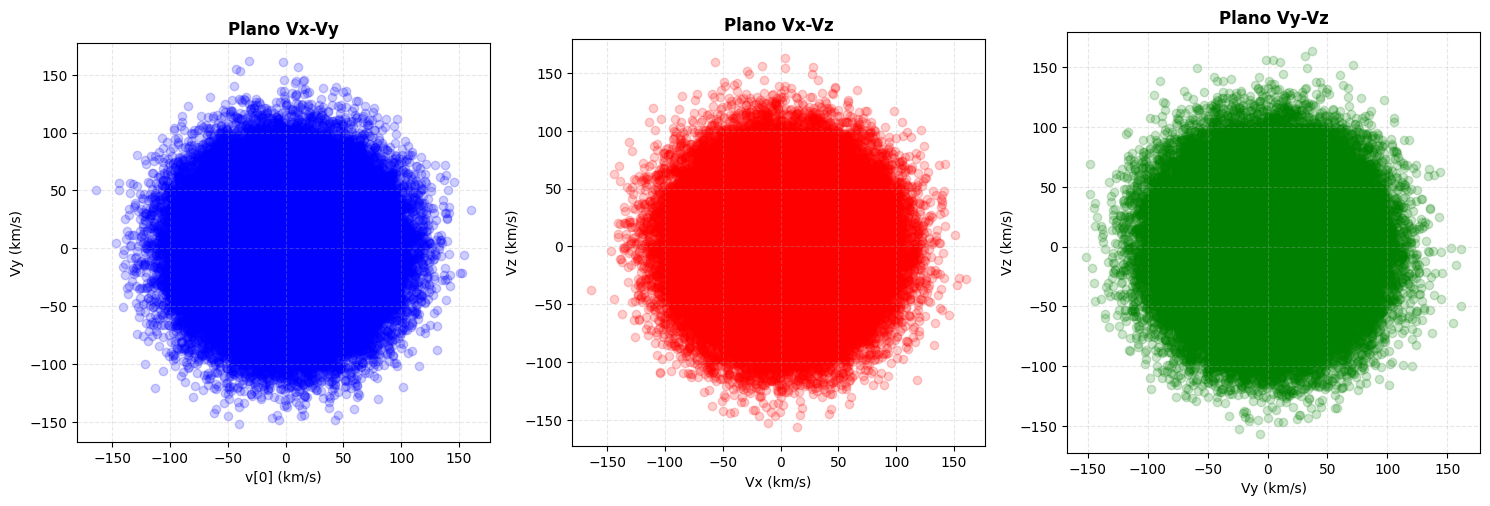

In [8]:
# Crear figura y subgráficos en una fila
n = 0.2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico Vx vs Vy
axes[0].scatter(v[0], v[1], c='b', alpha=n)
axes[0].set_xlabel("v[0] (km/s)")
axes[0].set_ylabel("Vy (km/s)")
axes[0].set_title("Plano Vx-Vy",  fontweight="bold")
axes[0].set_aspect("equal")
axes[0].grid(True, linestyle="--", alpha=0.3)

# Gráfico Vx vs Vz
axes[1].scatter(v[0], v[2], c='r', alpha=n)
axes[1].set_xlabel("Vx (km/s)")
axes[1].set_ylabel("Vz (km/s)")
axes[1].set_title("Plano Vx-Vz",  fontweight="bold")
axes[1].set_aspect("equal")
axes[1].grid(True, linestyle="--", alpha=0.3)

# Gráfico Vy vs Vz
axes[2].scatter(v[1], v[2], c='g', alpha=n)
axes[2].set_xlabel("Vy (km/s)")
axes[2].set_ylabel("Vz (km/s)")
axes[2].set_title("Plano Vy-Vz",  fontweight="bold")
axes[2].set_aspect("equal")
axes[2].grid(True, linestyle="--", alpha=0.3)


# Ajustar espaciado
plt.tight_layout()
plt.show()

In [9]:
# Variables de entrada
vx, vy, vz = v  # Extraer componentes de velocidad
x, y, z = r     # Extraer componentes de posición

# Calcular r (magnitud de la posición)
r_mag = np.sqrt(x**2 + y**2 + z**2)

# Calcular theta y phi
theta = np.arccos(z / r_mag)  # Ángulo polar
phi = np.arctan2(y, x)        # Ángulo azimutal

# Transformación de velocidades
vr = (x * vx + y * vy + z * vz) / r_mag
vtheta = ((x * vx *z + y * vy * z - vz*(x**2 + y**2)) / (r_mag * np.sqrt(x**2 + y**2))) 
#vtheta = ((x * vx + y * vy) / r_mag) * np.cos(theta) - vz * np.sin(theta)
vphi = (-y * vx + x * vy) / np.sqrt(x**2 + y**2)

#vr = np.sin(theta) * np.cos(phi) * vx + np.sin(theta) * np.sin(phi) * vy + np.cos(theta) * vz
#vtheta = np.cos(theta) * np.cos(phi) * vx + np.cos(theta) * np.sin(phi) * vy - np.sin(theta) * vz
#vphi = -np.sin(phi) * vx + np.cos(phi) * vy

# Guardar resultado en una variable
v_esfericas = np.array([vr, vtheta, vphi])

# Mostrar resultados
print("Velocidades en coordenadas esféricas:")
print("v_r:", vr)
print("v_theta:", vtheta)
print("v_phi:", vphi)

Velocidades en coordenadas esféricas:
v_r: [ 68.40884674  19.37650552  20.29059818 ...  28.74536319 -30.43378084
  14.93234133]
v_theta: [ 15.71155812   6.84861967 -48.48271693 ...  32.31116878   4.24907813
  -3.7707889 ]
v_phi: [ 31.91756698 -30.66510568 -29.81777696 ...  15.77640117  28.55829983
  10.40962954]


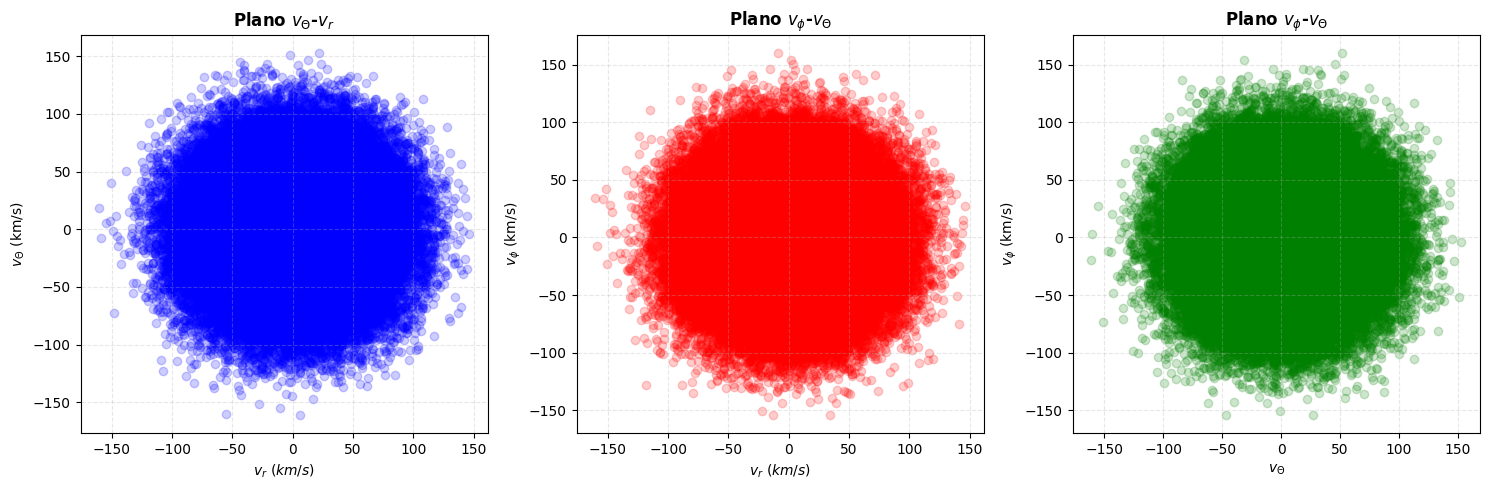

In [10]:
# Crear figura y subgráficos en una fila
n = 0.2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Gráfico Vx vs Vy
axes[0].scatter(v_esfericas[0], v_esfericas[1], c='b', alpha=n)
axes[0].set_xlabel("$v_r$ ($km/s$)")
axes[0].set_ylabel("$v_\Theta$ (km/s)")
axes[0].set_title("Plano $v_\Theta$-$v_r$",  fontweight="bold")
#axes[0].set_aspect("equal")
axes[0].grid(True, linestyle="--", alpha=0.3)

# Gráfico Vx vs Vz
axes[1].scatter(v_esfericas[0],v_esfericas[2], c='r', alpha=n)
axes[1].set_xlabel("$v_r$ ($km/s$)")
axes[1].set_ylabel("$v_\phi$ (km/s)")
axes[1].set_title("Plano $v_\phi$-$v_\Theta$",  fontweight="bold")
#axes[1].set_aspect("equal")
axes[1].grid(True, linestyle="--", alpha=0.3)

# Gráfico Vy vs Vz
axes[2].scatter(v_esfericas[1], v_esfericas[2], c='g', alpha=n)
axes[2].set_xlabel("$v_{\Theta}$")
axes[2].set_ylabel("$v_\phi$ (km/s)")
axes[2].set_title("Plano $v_\phi$-$v_\Theta$",  fontweight="bold")
#axes[2].set_aspect("equal")
axes[2].grid(True, linestyle="--", alpha=0.3)


# Ajustar espaciado
plt.tight_layout()
plt.show()

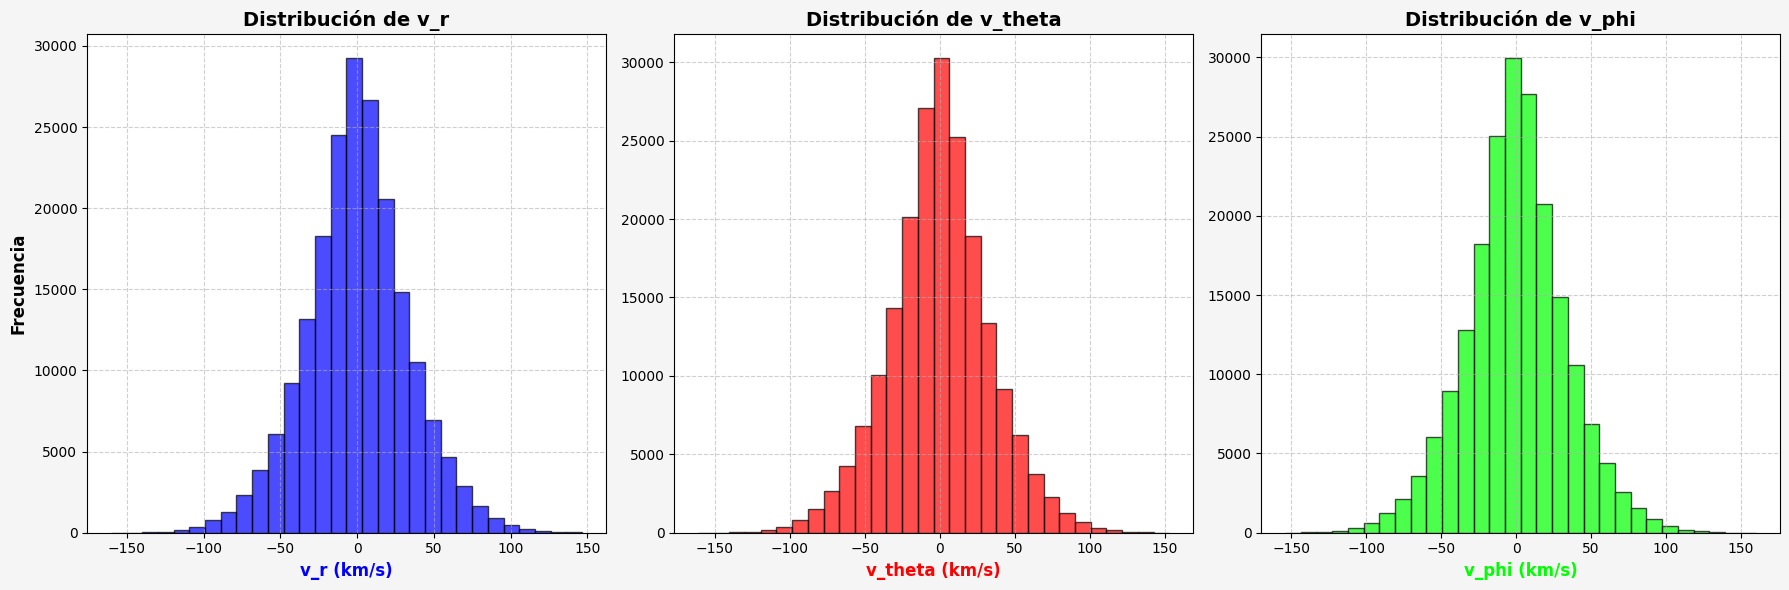

In [11]:
# Crear figura y subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#f5f5f5")

# Estilos generales
hist_kwargs = dict(bins=30, edgecolor="black", alpha=0.7)

# Histograma de v_r
axes[0].hist(vr, color="blue", **hist_kwargs)
axes[0].set_xlabel("v_r (km/s)", fontsize=12, fontweight="bold", color="blue")
axes[0].set_ylabel("Frecuencia", fontsize=12, fontweight="bold")
#axes[0].axvline(np.mean(vr), color="green", linestyle="--", linewidth=2, label="Media")
axes[0].set_title("Distribución de v_r", fontsize=14, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_theta
axes[1].hist(vtheta, color="red", **hist_kwargs)
axes[1].set_xlabel("v_theta (km/s)", fontsize=12, fontweight="bold", color="red")
axes[1].set_title("Distribución de v_theta", fontsize=14, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_phi
axes[2].hist(vphi, color="lime", **hist_kwargs)
axes[2].set_xlabel("v_phi (km/s)", fontsize=12, fontweight="bold", color="lime")
axes[2].set_title("Distribución de v_phi", fontsize=14, fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.6)

# Ajustar espaciado
plt.tight_layout()
plt.show()

In [12]:
cov_matrix = np.cov(v_esfericas)
print("Matriz de covarianza de velocidades:")
print(cov_matrix)

Matriz de covarianza de velocidades:
[[1118.19006528    3.13668674   -1.74870871]
 [   3.13668674 1119.87955198    2.38318054]
 [  -1.74870871    2.38318054 1117.36973825]]


In [13]:
corr_matrix = np.corrcoef(v_esfericas)

print("Matriz de correlación de velocidades:")
print(corr_matrix)

Matriz de correlación de velocidades:
[[ 1.          0.00280303 -0.00156445]
 [ 0.00280303  1.          0.00213046]
 [-0.00156445  0.00213046  1.        ]]


In [14]:
# Calcular dispersión de velocidades
sigma_r2 = np.var(vr)  # Dispersión cuadrática en r
sigma_theta2 = np.var(vtheta)  # Dispersión cuadrática en θ
sigma_phi2 = np.var(vphi)  # Dispersión cuadrática en φ

# Dispersión tangencial
sigma_t2 = (sigma_theta2 + sigma_phi2) 

# Parámetro de anisotropía
beta = 1 - (sigma_t2 / (2 * sigma_r2))

print(f"Parámetro de anisotropía: β = {beta}")

Parámetro de anisotropía: β = -0.00038864576190800193


# Punto b

In [15]:
# Calcular los promedios de las velocidades
vr_mean, vtheta_mean, vphi_mean = np.mean(vr), np.mean(vtheta), np.mean(vphi)

# Calcular los productos promediados
vr_vr_mean = np.mean(vr * vr)
vtheta_vtheta_mean = np.mean(vtheta * vtheta)
vphi_vphi_mean = np.mean(vphi * vphi)
vr_vtheta_mean = np.mean(vr * vtheta)
vr_vphi_mean = np.mean(vr * vphi)
vtheta_vphi_mean = np.mean(vtheta * vphi)

# Construir el tensor de dispersión en coordenadas esféricas
tensor_dispersion_spherical = np.array([
    [vr_mean * vr_mean, vr_mean * vtheta_mean, vr_mean * vphi_mean],
    [vr_mean * vtheta_mean, vtheta_mean * vtheta_mean, vtheta_mean * vphi_mean],
    [vr_mean * vphi_mean, vtheta_mean * vphi_mean, vphi_mean * vphi_mean]
])

# Mostrar resultados
print("Tensor de dispersión de velocidades en coordenadas esféricas:")
print(tensor_dispersion_spherical)

Tensor de dispersión de velocidades en coordenadas esféricas:
[[ 0.00257952 -0.00052135  0.00413856]
 [-0.00052135  0.00010537 -0.00083645]
 [ 0.00413856 -0.00083645  0.00663986]]


In [16]:
# Construir el tensor de dispersión (con término negativo)
tensor_dispersion_with_neg = np.array([
    [vr_vr_mean - vr_mean * vr_mean, vr_vtheta_mean - vr_mean * vtheta_mean, vr_vphi_mean - vr_mean * vphi_mean],
    [vr_vtheta_mean - vr_mean * vtheta_mean, vtheta_vtheta_mean - vtheta_mean * vtheta_mean, vtheta_vphi_mean - vtheta_mean * vphi_mean],
    [vr_vphi_mean - vr_mean * vphi_mean, vtheta_vphi_mean - vtheta_mean * vphi_mean, vphi_vphi_mean - vphi_mean * vphi_mean]
])

tensor_dispersion_without_neg = np.array([
    [vr_vr_mean , vr_vtheta_mean , vr_vphi_mean ],
    [vr_vtheta_mean , vtheta_vtheta_mean , vtheta_vphi_mean ],
    [vr_vphi_mean , vtheta_vphi_mean , vphi_vphi_mean ]
])

# Calcular la diferencia relativa
relative_difference = abs((tensor_dispersion_with_neg - tensor_dispersion_without_neg)) / tensor_dispersion_without_neg *100

# Mostrar resultados
print("Tensor de dispersión (con término negativo):")
print(tensor_dispersion_with_neg)

print("\nTensor de dispersión (sin término negativo, usando np.cov):")
print(tensor_dispersion_without_neg)

print("\nDiferencia relativa:")
print(relative_difference)

Tensor de dispersión (con término negativo):
[[1118.18447433    3.13667106   -1.74869997]
 [   3.13667106 1119.87395258    2.38316862]
 [  -1.74869997    2.38316862 1117.3641514 ]]

Tensor de dispersión (sin término negativo, usando np.cov):
[[1118.18705385    3.1361497    -1.74456141]
 [   3.1361497  1119.87405795    2.38233217]
 [  -1.74456141    2.38233217 1117.37079126]]

Diferencia relativa:
[[ 2.30687384e-04  1.66239232e-02 -2.37226106e-01]
 [ 1.66239232e-02  9.40920936e-06  3.51106147e-02]
 [-2.37226106e-01  3.51106147e-02  5.94239978e-04]]


# Punto c

In [403]:
# Definir bins de radio
r_min, r_max = 0, np.max(r_mag)
num_bins = 15  # Puedes ajustar el número de cascarones
r_bins = np.linspace(r_min, r_max, num_bins + 1)  # Bordes de los bins

# Inicializar listas para almacenar la dispersión en cada bin
sigma_r, sigma_theta, sigma_phi = [], [], []
r_centers = []  # Para graficar en el centro de cada bin

# Calcular la dispersión en cada cascarón
for i in range(num_bins):
    r_low, r_high = r_bins[i], r_bins[i+1]
    
    # Seleccionar partículas dentro del cascarón
    mask = (r_mag >= r_low) & (r_mag < r_high)
    indices = np.where(mask)[0]  # Obtener índices válidos
    
    if len(indices) > 1:  # Solo calcular si hay suficientes datos
        sigma_r.append(np.std(vr[indices]))
        sigma_theta.append(np.std(vtheta[indices]))
        sigma_phi.append(np.std(vphi[indices]))
        r_centers.append((r_low + r_high) / 2)

# Convertir listas a arrays
r_centers = np.array(r_centers)
sigma_r = np.array(sigma_r)
sigma_theta = np.array(sigma_theta)
sigma_phi = np.array(sigma_phi)

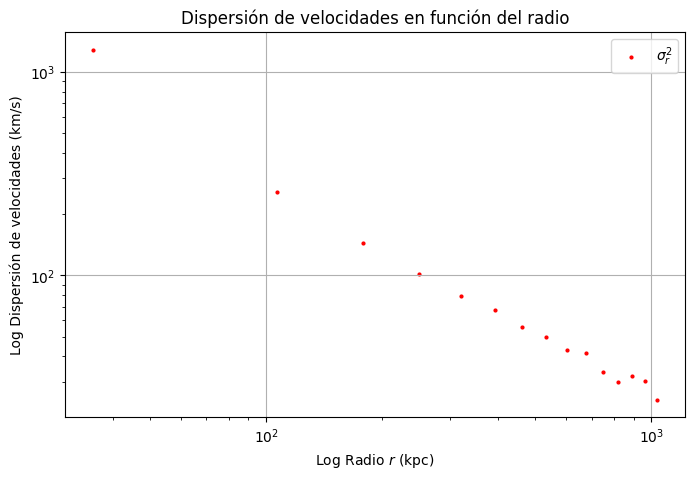

In [449]:
# Graficar la dispersión en función del radio
plt.figure(figsize=(8, 5))
plt.scatter(r_centers, sigma_r**2, label=r'$\sigma_r^2$', marker='o', s = 4.0, color = 'red')#, linestyle='-')
#plt.scatter(r_centers, sigma_theta**2, label=r'$\sigma_\theta$', marker='s')#, linestyle='--')
#plt.scatter(r_centers, sigma_phi**2, label=r'$\sigma_\phi$', marker='d')#, linestyle=':')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Log Radio $r$ (kpc)")
plt.ylabel("Log Dispersión de velocidades (km/s)")
plt.legend()
plt.grid()
plt.title("Dispersión de velocidades en función del radio")
plt.show()

# Punto d

In [405]:
# Definir bins de radio
r_min, r_max = 0, np.max(r_mag)
num_bins = 15  # Puedes ajustar el número de cascarones
r_bins = np.linspace(r_min, r_max, num_bins + 1)  # Bordes de los bins

# Inicializar listas para almacenar la dispersión en cada bin
rho = []
r_centers = []  # Para graficar en el centro de cada bin

# Calcular la dispersión en cada cascarón
for i in range(num_bins):
    r_low, r_high = r_bins[i], r_bins[i+1]
    
    # Seleccionar partículas dentro del cascarón
    mask = (r_mag >= r_low) & (r_mag < r_high)
    indices = np.where(mask)[0]  # Obtener índices válidos
    
    if len(indices) > 1:  # Solo calcular si hay suficientes datos
        r_centers.append((r_low + r_high) / 2)
        rho.append(len(indices)/((4/3)*np.pi*(r_high**3-r_low**3)))

rho = np.array(rho)

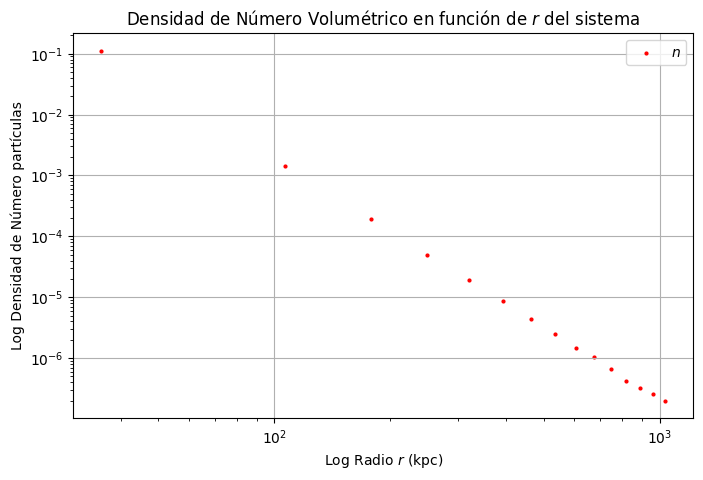

In [452]:
# Graficar la dispersión en función del radio
plt.figure(figsize=(8, 5))
plt.scatter(r_centers, rho, label=r'$n$', marker='o', s = 4.0, color = 'red')#, linestyle='-')
#plt.scatter(r_centers, sigma_theta**2, label=r'$\sigma_\theta$', marker='s')#, linestyle='--')
#plt.scatter(r_centers, sigma_phi**2, label=r'$\sigma_\phi$', marker='d')#, linestyle=':')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("Log Radio $r$ (kpc)")
plt.ylabel("Log Densidad de Número partículas")
plt.legend()
plt.grid()
plt.title("Densidad de Número Volumétrico en función de $r$ del sistema")
plt.show()

$$M(r) = - \frac{r\sigma^2}{G}\left[ \frac{d\ln\rho}{d\ln{ r}}  + \frac{d\ln \sigma^2}{d \ln {r}} + 2\beta \right]$$

$$M(r) = \left(-\frac{r^2}{G} \right) \frac{1}{p(r)} \frac{d}{dr} \left( p(r) \cdot \sigma^2(r) \right)$$

In [428]:
# Calculamos las derivadas logarítmicas usando diferencias finitas
dln_rho_dln_r = np.gradient(np.log(rho), np.log(r_centers))
dln_sigma2_dln_r = np.gradient(np.log(sigma_r**2 / 887.2), np.log(r_centers))

G = 43007.1

# Calculamos la masa M(r)
#M_r = abs(- (r_centers * sigma_r**2 / G) * (sigma_r**2 * dln_rho_dln_r + rho * dln_sigma2_dln_r))
M_r = - (r_centers * sigma_r**2 / (G*887.2)) * ( (1/rho)*dln_rho_dln_r + dln_sigma2_dln_r)
M_r

array([4.40134179e-02, 1.97187622e+00, 1.40799821e+01, 5.11550709e+01,
       1.35283145e+02, 3.23583037e+02, 6.16784254e+02, 1.13177235e+03,
       1.68908833e+03, 2.84127395e+03, 4.75622171e+03, 5.97491151e+03,
       6.94777586e+03, 9.83182310e+03, 1.14533373e+04])

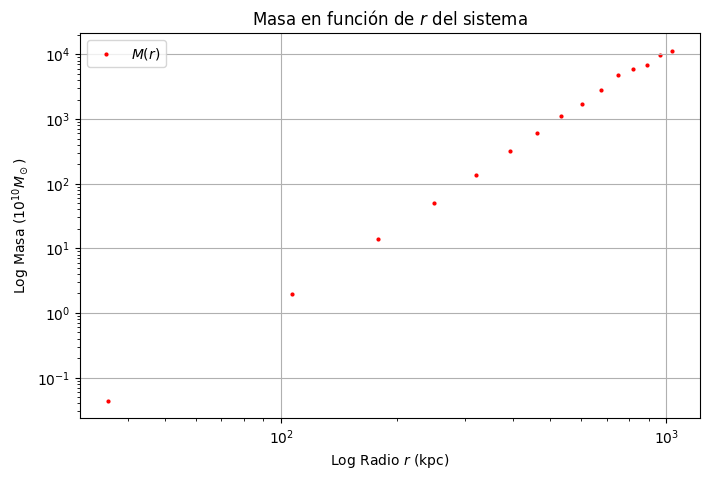

In [453]:
# Graficar la dispersión en función del radio
plt.figure(figsize=(8, 5))
plt.scatter(r_centers, M_r, label=r'$M(r)$', marker='o', s = 4.0, color = 'red')#, linestyle='-')
#plt.scatter(r_centers, sigma_theta**2, label=r'$\sigma_\theta$', marker='s')#, linestyle='--')
#plt.scatter(r_centers, sigma_phi**2, label=r'$\sigma_\phi$', marker='d')#, linestyle=':')

plt.xscale('log')
plt.yscale('log')
#plt.ylim(1,12)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Log Radio $r$ (kpc)")
plt.ylabel("Log Masa ($10^{10} M_\odot$)")
plt.legend()
plt.grid()
plt.title("Masa en función de $r$ del sistema")
plt.show()

In [430]:
M_r[-1]

11453.337317330239

In [ ]:
!pip install galpy
from galpy.potential import PlummerPotential

Masa total ajustada: 3091460092037.966
Radio característico ajustado: 666068.262 kpc
Masa total ajustada: 11512.482


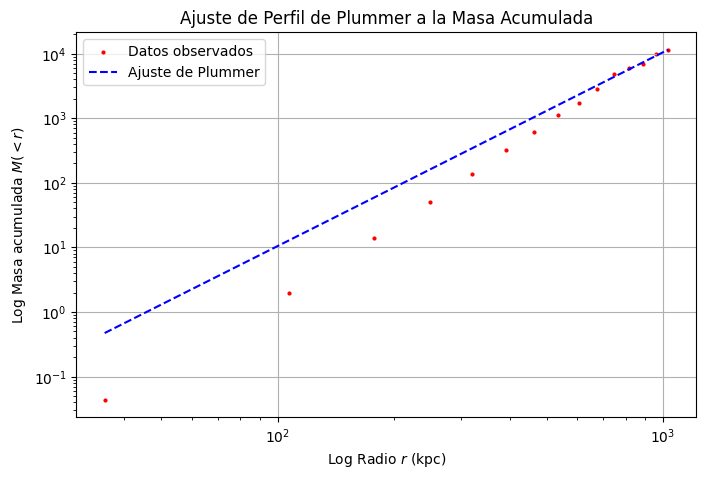

In [456]:
from scipy.optimize import curve_fit

# Definir la función de Plummer para masa acumulada
def plummer_mass(r, M, a):
    return M * (r**3) / ((r**2 + a**2) ** (3/2))

# Ajustar la función de Plummer a los datos observados
popt, pcov = curve_fit(plummer_mass, r_centers, M_r, p0=[np.max(M_r), np.median(r_centers)], maxfev=4500)

# Parámetros ajustados
M_fit, a_fit = popt

print(f"Masa total ajustada: {M_fit:.3f}")
print(f"Radio característico ajustado: {a_fit:.3f} kpc")

# Generar la curva teórica con los parámetros ajustados
r_fit = np.linspace(min(r_centers), max(r_centers), 1000)
M_fit_curve = plummer_mass(r_fit, M_fit, a_fit)

print(f"Masa total ajustada: {M_fit_curve[-1]:.3f}")


# Graficar datos observacionales y el ajuste
plt.figure(figsize=(8, 5))
plt.scatter(r_centers, M_r, label="Datos observados",s = 4.0, color='red')
plt.plot(r_fit, M_fit_curve, label="Ajuste de Plummer", color='blue', linestyle="--")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Log Radio $r$ (kpc)")
plt.ylabel("Log Masa acumulada $M(<r)$")
plt.title("Ajuste de Perfil de Plummer a la Masa Acumulada")
plt.legend()
plt.grid(True)
plt.show()

# Punto 2

In [25]:
df2 = pd.read_csv("sub_MDPLHal_1e12.316.csv", delim_whitespace=True, names=["x", "y", "z"])
df3 = pd.read_csv("sub_MDPLHal_1e12.316_V2.csv", delim_whitespace=True, names=["x", "y", "z"])


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_12916\136461995.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df2 = pd.read_csv("sub_MDPLHal_1e12.316.csv", delim_whitespace=True, names=["x", "y", "z"])
C:\Users\USUARIO\AppData\Local\Temp\ipykernel_12916\136461995.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df3 = pd.read_csv("sub_MDPLHal_1e12.316_V2.csv", delim_whitespace=True, names=["x", "y", "z"])


In [458]:
r2 = np.array([df2['x'], df2['y'], df2['z']])  # Extraer componentes

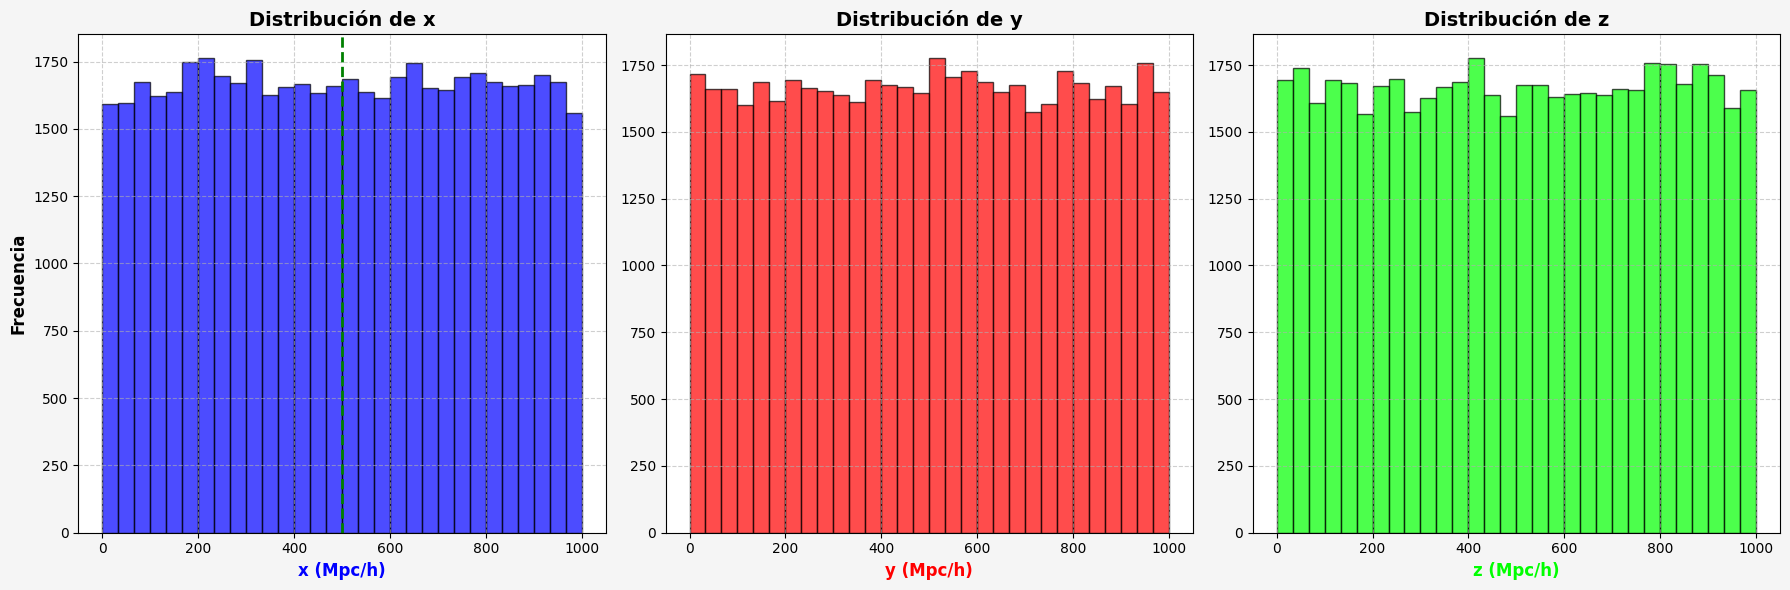

In [27]:
# Crear figura y subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#f5f5f5")

# Estilos generales
hist_kwargs = dict(bins=30, edgecolor="black", alpha=0.7)

# Histograma de v_r
axes[0].hist(r2[0], color="blue", **hist_kwargs)
axes[0].set_xlabel("x (Mpc/h)", fontsize=12, fontweight="bold", color="blue")
axes[0].set_ylabel("Frecuencia", fontsize=12, fontweight="bold")
axes[0].axvline(np.mean(r2[0]), color="green", linestyle="--", linewidth=2, label="Media")
axes[0].set_title("Distribución de x", fontsize=14, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_theta
axes[1].hist(r2[1], color="red", **hist_kwargs)
axes[1].set_xlabel("y (Mpc/h)", fontsize=12, fontweight="bold", color="red")
axes[1].set_title("Distribución de y", fontsize=14, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_phi
axes[2].hist(r2[2], color="lime", **hist_kwargs)
axes[2].set_xlabel("z (Mpc/h)", fontsize=12, fontweight="bold", color="lime")
axes[2].set_title("Distribución de z", fontsize=14, fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.6)

# Ajustar espaciado
plt.tight_layout()
plt.show()

In [401]:
r3 = np.array([df3['x'], df3['y'], df3['z']])  # Extraer componentes

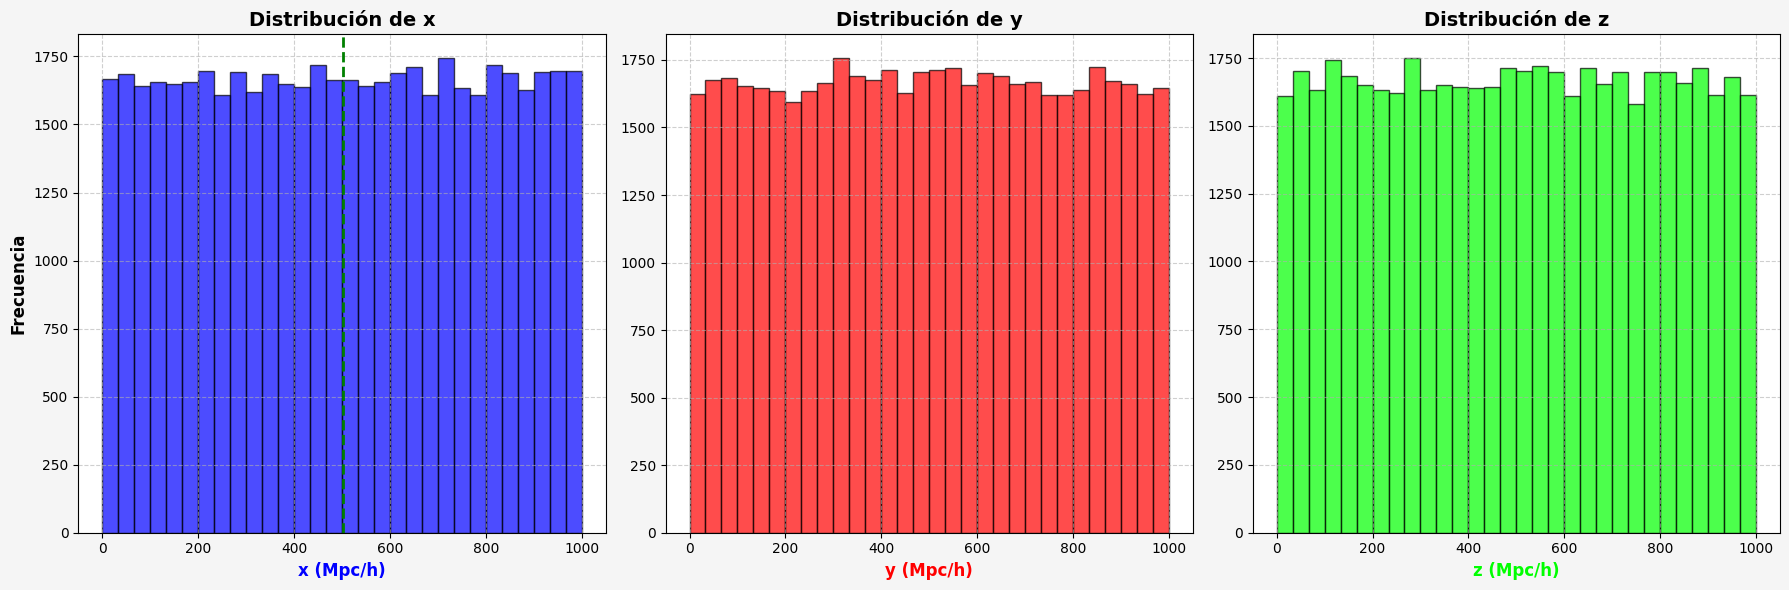

In [402]:
# Crear figura y subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#f5f5f5")

# Estilos generales
hist_kwargs = dict(bins=30, edgecolor="black", alpha=0.7)

# Histograma de v_r
axes[0].hist(r3[0], color="blue", **hist_kwargs)
axes[0].set_xlabel("x (Mpc/h)", fontsize=12, fontweight="bold", color="blue")
axes[0].set_ylabel("Frecuencia", fontsize=12, fontweight="bold")
axes[0].axvline(np.mean(r3[0]), color="green", linestyle="--", linewidth=2, label="Media")
axes[0].set_title("Distribución de x", fontsize=14, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_theta
axes[1].hist(r3[1], color="red", **hist_kwargs)
axes[1].set_xlabel("y (Mpc/h)", fontsize=12, fontweight="bold", color="red")
axes[1].set_title("Distribución de y", fontsize=14, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_phi
axes[2].hist(r3[2], color="lime", **hist_kwargs)
axes[2].set_xlabel("z (Mpc/h)", fontsize=12, fontweight="bold", color="lime")
axes[2].set_title("Distribución de z", fontsize=14, fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.6)

# Ajustar espaciado
plt.tight_layout()
plt.show()

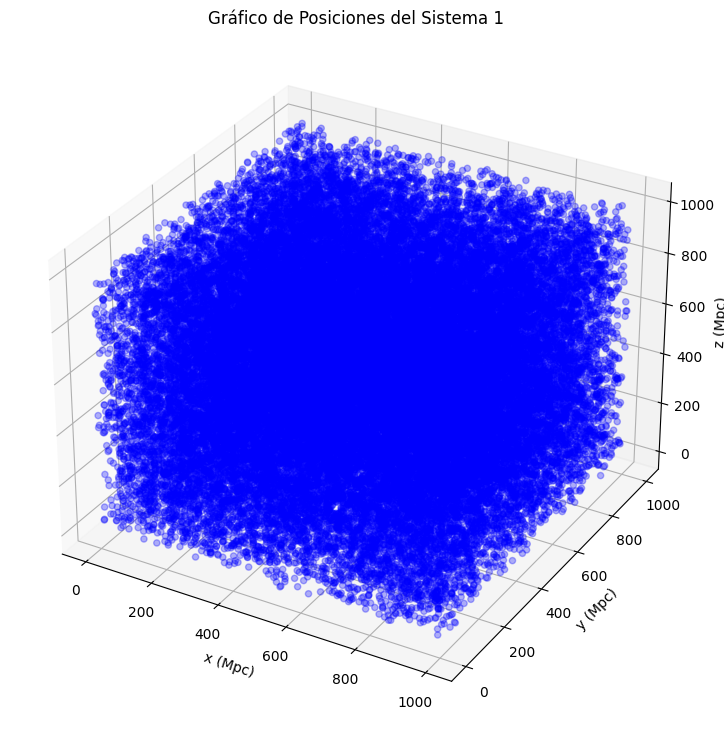

In [464]:
# Crear la figura 3D
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos
ax.scatter(r2[0], r2[1], r2[2], c='b', marker='o', alpha=0.3)

# Etiquetas de los ejes
ax.set_xlabel("x (Mpc)")
ax.set_ylabel("y (Mpc)")
ax.set_zlabel("z (Mpc)")

# Título
ax.set_title("Gráfico de Posiciones del Sistema 1")

# Mostrar la gráfica
plt.show()

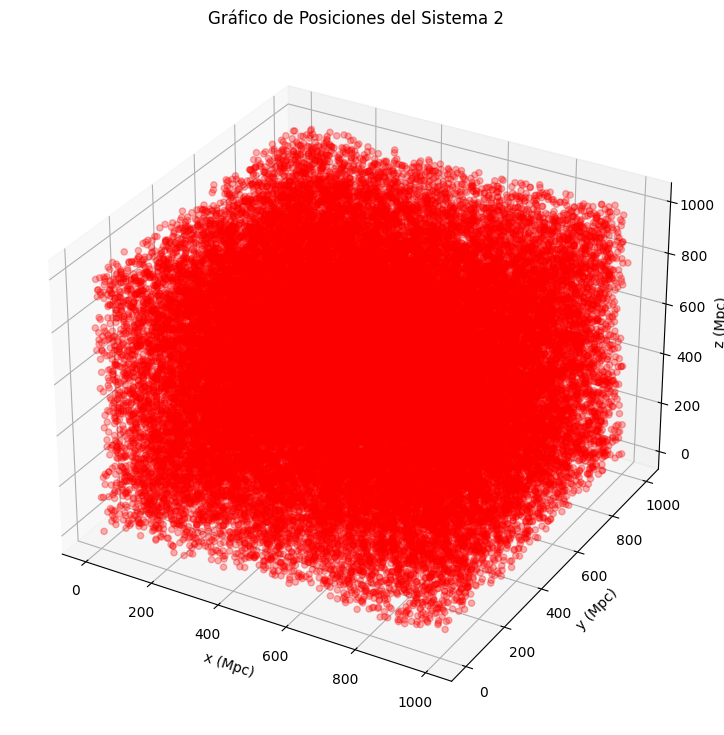

In [465]:
# Crear la figura 3D
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# Graficar los puntos
ax.scatter(r3[0], r3[1], r3[2], c='r', marker='o', alpha=0.3)

# Etiquetas de los ejes
ax.set_xlabel("x (Mpc)")
ax.set_ylabel("y (Mpc)")
ax.set_zlabel("z (Mpc)")

# Título
ax.set_title("Gráfico de Posiciones del Sistema 2")

# Mostrar la gráfica
plt.show()

In [466]:
r2 = np.stack((df2['x'], df2['y'], df2['z']), axis=1)

In [499]:
#Cambiando el sistema de referencia al centro de la caja
# Calcular el centroide (promedio de cada coordenada)
x2_mean = np.mean(r2[:,0])
y2_mean = np.mean(r2[:,1])
z2_mean = np.mean(r2[:,2])

# Restar el centroide para centrar la distribución
x2_centered = r2[:,0] - x2_mean #Caja de 1Gpc
y2_centered = r2[:,1] - y2_mean
z2_centered = r2[:,2] - z2_mean


r2_centered = np.stack((x2_centered, y2_centered, z2_centered), axis=1) #Coordendas respecto al centro de la caja

# Calcular r (magnitud de la posición)
r2_mag = np.sqrt(x2_centered**2 + y2_centered**2 + z2_centered**2)



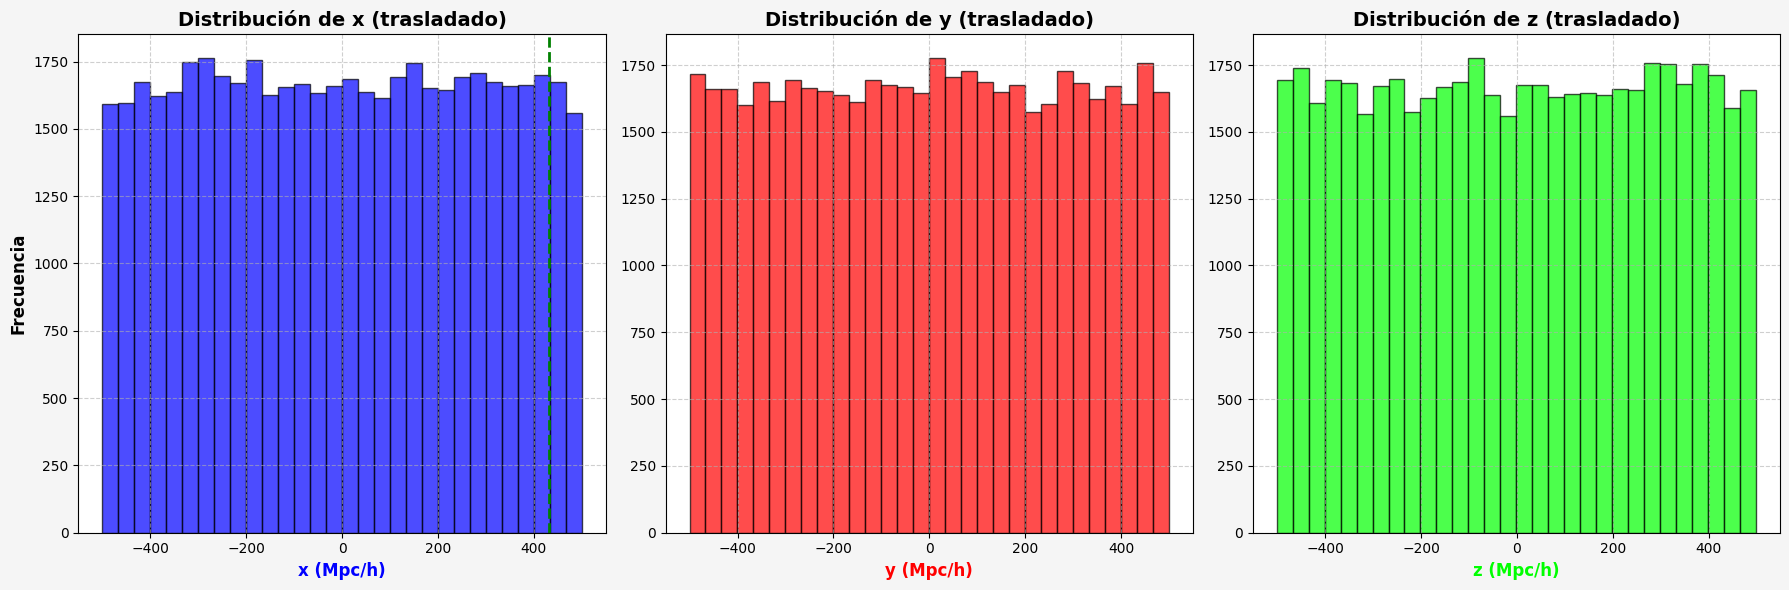

In [504]:
# Crear figura y subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#f5f5f5")

# Estilos generales
hist_kwargs = dict(bins=30, edgecolor="black", alpha=0.7)

# Histograma de v_r
axes[0].hist(x2_centered, color="blue", **hist_kwargs)
axes[0].set_xlabel("x (Mpc/h)", fontsize=12, fontweight="bold", color="blue")
axes[0].set_ylabel("Frecuencia", fontsize=12, fontweight="bold")
axes[0].axvline(np.mean(r2[0]), color="green", linestyle="--", linewidth=2, label="Media")
axes[0].set_title("Distribución de x (trasladado)", fontsize=14, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_theta
axes[1].hist(y2_centered, color="red", **hist_kwargs)
axes[1].set_xlabel("y (Mpc/h)", fontsize=12, fontweight="bold", color="red")
axes[1].set_title("Distribución de y (trasladado)", fontsize=14, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_phi
axes[2].hist(z2_centered, color="lime", **hist_kwargs)
axes[2].set_xlabel("z (Mpc/h)", fontsize=12, fontweight="bold", color="lime")
axes[2].set_title("Distribución de z (trasladado)", fontsize=14, fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.6)

# Ajustar espaciado
plt.tight_layout()
plt.show()

In [468]:
def centro(r,cota): #Función para calcular puntos en una caja de lado = cota
    R = []
    for i in range(len(r)):
        if  -cota < r[i][0] < cota:
            if -cota <r[i][1] <cota:
                if -cota < r[i][2] <cota:
                    R.append(np.array([r[i][0], r[i][1], r[i][2]]))
    return R

In [497]:
a = centro(r2_centered, 231) #particulas dentro de una caja de lado x en el centro
len(a)

4998

In [479]:
#Me recibe las coordenadas respecto al centro y la particula a la cual quiero mover el centro
def recenter(r, center):
    # Calcular el centroide (promedio de cada coordenada)
    x_mean = center[0]
    y_mean = center[1]
    z_mean = center[2]

    # Restar el centroide para centrar la distribución
    x_centered = r[:,0] - x_mean #Caja de 1Gpc
    y_centered = r[:,1] - y_mean
    z_centered = r[:,2] - z_mean


    r_centered = np.array([x_centered, y_centered, z_centered])

    # Calcular r (magnitud de la posición)
    r_mag = np.sqrt(x_centered**2 + y_centered**2 + z_centered**2)
    return r_mag, r_centered


In [480]:
R2_new = []
R2_mag = []
for i in range(len(a)):
    R2_mag.append(recenter(r2_centered, a[i])[0]) #Arreglo con todos los nuevo R de todas las particulas en cada recentrado
    R2_new.append(recenter(r2_centered, a[i])[1]) #Arreglo con todas las nuevas posiciones todas las particulas en cada recentrado

In [481]:
def dnumero(Rmag): #Funcion para calcular número de particulas en r y r + dr
    r_min, r_max = 0, 200 #Vamos a calcularlo en una esfera con 200 Mpc de radio
    num_bins = 25  # Puedes ajustar el número de cascarones
    r_bins = np.linspace(r_min, r_max, num_bins + 1)  # Bordes de los bins

    # Inicializar listas para almacenar la dispersión en cada bin
    rho = []
    r_centers = []  # Para graficar en el centro de cada bin

    # Calcular la dispersión en cada cascarón
    for i in range(num_bins):
        r_low, r_high = r_bins[i], r_bins[i+1]
        
        # Seleccionar partículas dentro del cascarón
        mask = (Rmag >= r_low) & (Rmag < r_high)
        indices = np.where(mask)[0]  # Obtener índices válidos
        
        r_centers.append((r_low + r_high) / 2)
        #rho.append(len(indices)/((4/3)*np.pi*(r_high**3-r_low**3)))
        rho.append(len(indices))

    return np.array(rho), np.array(r_centers)

In [485]:
xi = []
r_centers2 = dnumero(R2_mag[0])[1]
for i in range(len(R2_mag)):
    xi.append(dnumero(R2_mag[i])[0])

xi_tot = np.sum(xi, axis=0) / len(r_centers2)
prob = xi_tot / np.sum(xi_tot) #probabilidad de datos

In [486]:
np.sum(xi_tot) #Número total de datos

342608.28

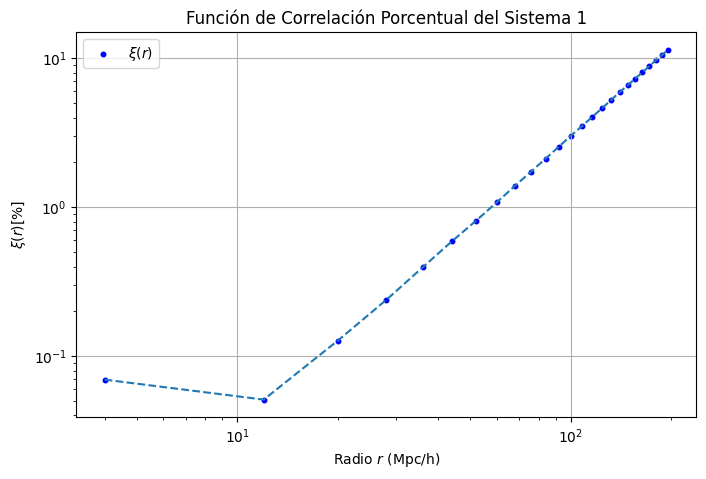

In [531]:
# Graficar la dispersión en función del radio
plt.figure(figsize=(8, 5))
plt.plot(r_centers2, prob*100, linestyle='--')
plt.scatter(r_centers2, prob*100, label=r'$\xi(r)$', marker='o', s = 10.5, color = 'blue')#, linestyle='-')


#plt.ylim(1,12)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Radio $r$ (Mpc/h)")
plt.ylabel(r"$\xi(r)[\%] $")
plt.legend()
plt.grid()
plt.title("Función de Correlación Porcentual del Sistema 1")
plt.show()

# Sistema 2

In [506]:
r3 = np.stack((df3['x'], df3['y'], df3['z']), axis=1)

In [507]:
#Cambiando el sistema de referencia al centro de la caja
# Calcular el centroide (promedio de cada coordenada)
x3_mean = np.mean(r3[:,0])
y3_mean = np.mean(r3[:,1])
z3_mean = np.mean(r3[:,2])

# Restar el centroide para centrar la distribución
x3_centered = r3[:,0] - x3_mean #Caja de 1Gpc
y3_centered = r3[:,1] - y3_mean
z3_centered = r3[:,2] - z3_mean


r3_centered = np.stack((x3_centered, y3_centered, z3_centered), axis=1) #Coordendas respecto al centro de la caja

# Calcular r (magnitud de la posición)
r3_mag = np.sqrt(x3_centered**2 + y3_centered**2 + z3_centered**2)

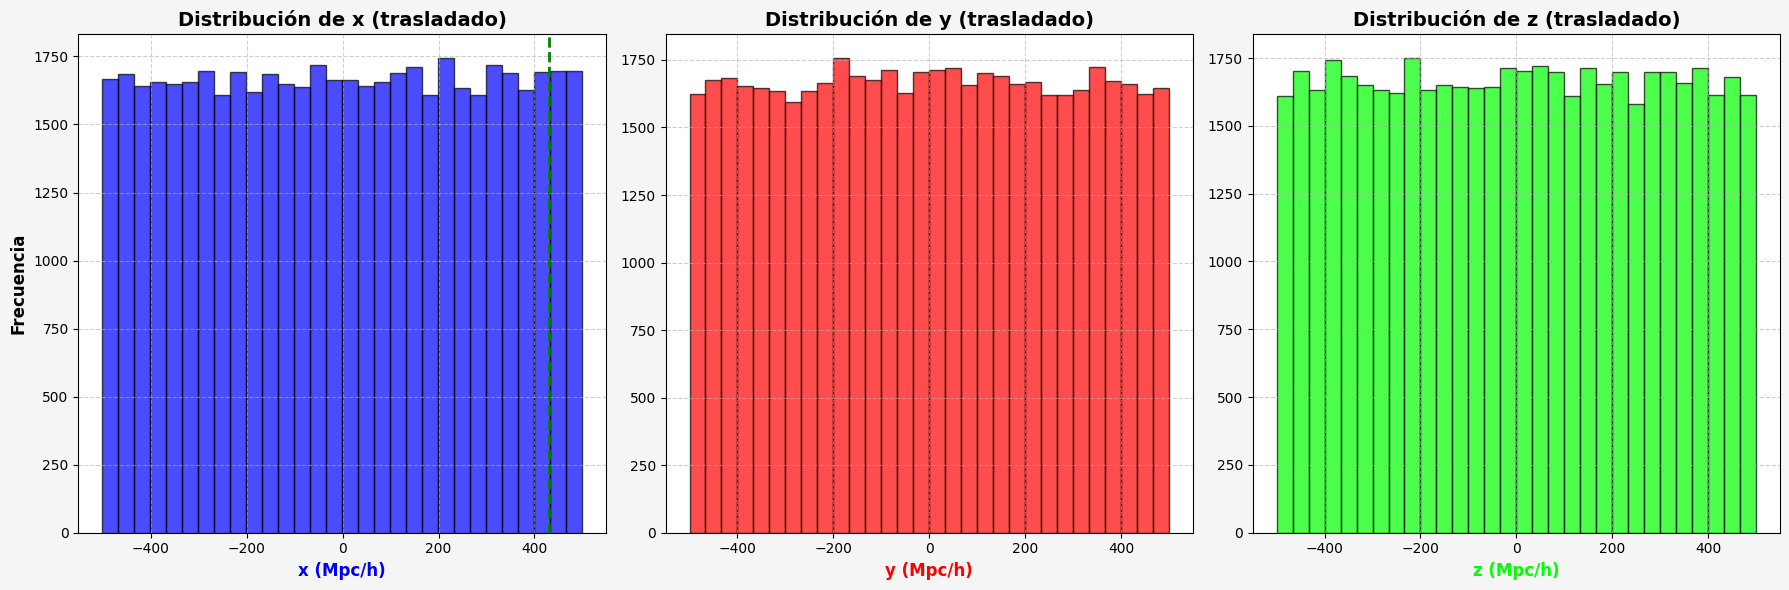

In [ ]:
# Crear figura y subgráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor="#f5f5f5")

# Estilos generales
hist_kwargs = dict(bins=30, edgecolor="black", alpha=0.7)

# Histograma de v_r
axes[0].hist(x3_centered, color="blue", **hist_kwargs)
axes[0].set_xlabel("x (Mpc/h)", fontsize=12, fontweight="bold", color="blue")
axes[0].set_ylabel("Frecuencia", fontsize=12, fontweight="bold")
axes[0].axvline(np.mean(r2[0]), color="green", linestyle="--", linewidth=2, label="Media")
axes[0].set_title("Distribución de x (trasladado)", fontsize=14, fontweight="bold")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_theta
axes[1].hist(y3_centered, color="red", **hist_kwargs)
axes[1].set_xlabel("y (Mpc/h)", fontsize=12, fontweight="bold", color="red")
axes[1].set_title("Distribución de y (trasladado)", fontsize=14, fontweight="bold")
axes[1].grid(True, linestyle="--", alpha=0.6)

# Histograma de v_phi
axes[2].hist(z3_centered, color="lime", **hist_kwargs)
axes[2].set_xlabel("z (Mpc/h)", fontsize=12, fontweight="bold", color="lime")
axes[2].set_title("Distribución de z (trasladado)", fontsize=14, fontweight="bold")
axes[2].grid(True, linestyle="--", alpha=0.6)

# Ajustar espaciado
plt.tight_layout()
plt.show()

In [512]:
a3 = centro(r3_centered, 232) #particulas dentro de una caja de 20x20x20 en el centro

R3_new = []
R3_mag = []

for i in range(len(a3)):
    R3_mag.append(recenter(r3_centered, a3[i])[0]) #Arreglo con todos los nuevo R de todas las particulas en cada recentrado
    R3_new.append(recenter(r3_centered, a3[i])[1]) #Arreglo con todas las nuevas posiciones todas las particulas en cada recentrado

In [513]:
xi3 = []
r_centers3 = dnumero(R3_mag[0])[1]
for i in range(len(R3_mag)):
    xi3.append(dnumero(R3_mag[i])[0])

xi_tot3 = np.sum(xi3, axis=0)
prob3 = xi_tot3/np.sum(xi_tot3) *100

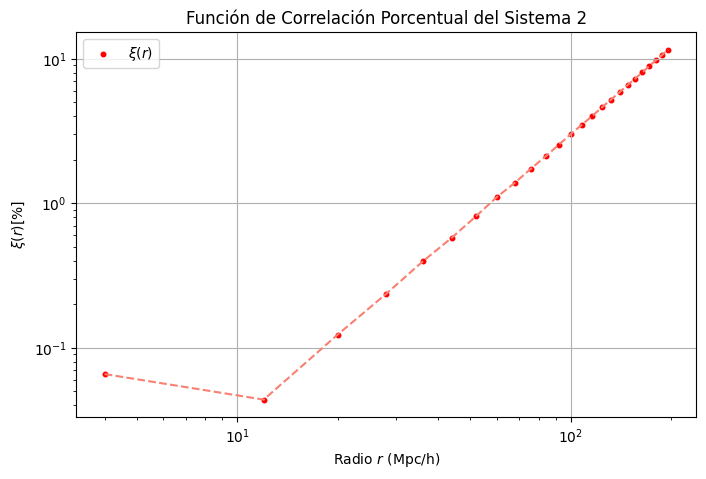

In [530]:
# Graficar la dispersión en función del radio
plt.figure(figsize=(8, 5))
plt.plot(r_centers3, prob3, linestyle='--', color = 'salmon')
plt.scatter(r_centers3, prob3, label=r'$\xi(r)$', marker='o', s = 10.5, color = 'red')#, linestyle='-')


#plt.ylim(1,12)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Radio $r$ (Mpc/h)")
plt.ylabel(r"$\xi(r) [\%]$")
plt.legend()
plt.grid()
plt.title("Función de Correlación Porcentual del Sistema 2")
plt.show()

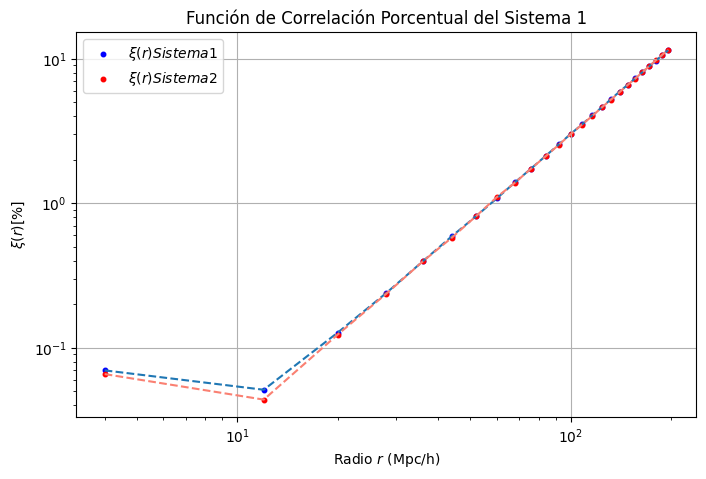

In [533]:
# Graficar la dispersión en función del radio
plt.figure(figsize=(8, 5))
plt.plot(r_centers2, prob*100, linestyle='--')
plt.scatter(r_centers2, prob*100, label=r'$\xi(r) Sistema 1$', marker='o', s = 10.5, color = 'blue')#, linestyle='-')
plt.plot(r_centers3, prob3, linestyle='--', color = 'salmon')
plt.scatter(r_centers3, prob3, label=r'$\xi(r) Sistema 2$', marker='o', s = 10.5, color = 'red')#, linestyle='-')



#plt.ylim(1,12)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Radio $r$ (Mpc/h)")
plt.ylabel(r"$\xi(r)[\%] $")
plt.legend()
plt.grid()
plt.title("Función de Correlación Porcentual del Sistema 1")
plt.show()